# Setup

In [4]:
%load_ext autoreload
%autoreload 2

In [13]:
import tpvalidator.datasets.miniprod as miniprod

datasets = miniprod.load_tp_presel_datasets(['radbkg'])

Key 'triggerAna/mctruths' not found in file.
Key 'triggerAna/mcneutrinos' not found in file.
Key 'triggerAna/mcparticles' not found in file.
Key 'triggerAna/simides' not found in file.


Dataset 'radbkg': 9930 events

{
    'backtracker': {'TPAlgTPCSimpleThreshold': {'offset_U': 8, 'offset_V': 1, 'offset_X': -7}},
    'geo': {'detector': 'dunevd10kt_3view_30deg_v5_refactored_1x8x6ref'},
    'tpg': {
        'tpmakerTPCSimpleThreshold::TriggerPrimitiveMaker': {
            'threshold_tpg_plane0': 45,
            'threshold_tpg_plane1': 45,
            'threshold_tpg_plane2': 45,
            'tool': 'TPAlgTPCSimpleThreshold'
        }
    }
}

In [78]:
import tpvalidator.mcprod.geometry as geo
import pandas as pd

def decorate_tpc_coords(tps, detgeo):
    # tps['tpc_view_channel'] = tps.channel.apply(lambda c: detgeo.tpc_view_channel(c)).astype('int16')
    tps[['inferred_view', 'tpc_view_channel']] = pd.DataFrame(tps.channel.apply(lambda c: detgeo.tpc_view_channel(c)).to_list(), index=tps.index).rename({0:'inferred_view', 1:'tpc_view_channel'}, axis=1)#.astype('int16')
    tps[['tpc_i', 'tpc_k']] = pd.DataFrame(tps.TPCSetID.apply(detgeo.tpc_id_to_grid).tolist(), index=tps.index).rename({0:'tpc_i', 1:'tpc_k'}, axis=1)
    tps['tpc_z_channel'] = (tps['tpc_view_channel']+detgeo.tpc_view_2_num_chans_sim*tps['tpc_k']).where(tps['readout_view'] == 2, -1)

decorate_tpc_coords(ev_tps, geo.FDVDGeometry_1x8x6)
display(ev_tps[['readout_view', 'inferred_view', 'tpc_i', 'tpc_k', 'tpc_z_channel']])


(ev_tps['readout_view'] == ev_tps['inferred_view']).all()

,readout_view,inferred_view,tpc_i,tpc_k,tpc_z_channel
0,0,0,0,0,-1
1,1,1,0,0,-1
2,1,1,0,0,-1
3,1,1,0,0,-1
4,1,1,0,0,-1
...,...,...,...,...,...
2221,2,2,7,5,1722
2222,2,2,7,5,1725
2223,2,2,7,5,1729
2224,2,2,7,5,1731


np.True_

In [79]:
radbkg_ws = datasets['radbkg']

ev_tps = radbkg_ws.tps.query(f'event_uid == {radbkg_ws.tps.event_uid.unique()[0]} & readout_view == 2').copy()

<Axes: xlabel='channel', ylabel='sample_start'>

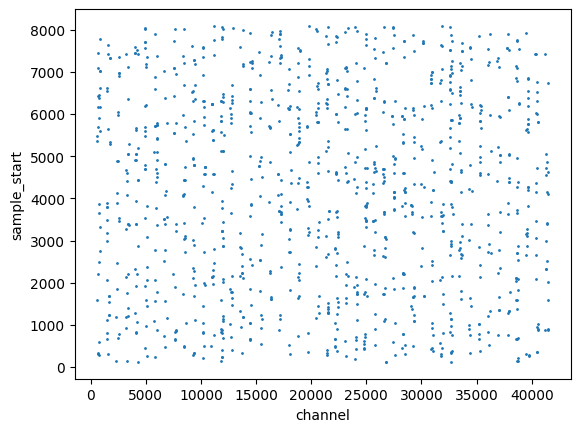

In [ ]:
ev_tps.plot.scatter(x='channel', y='sample_start', s=1)

<Axes: xlabel='channel', ylabel='sample_start'>

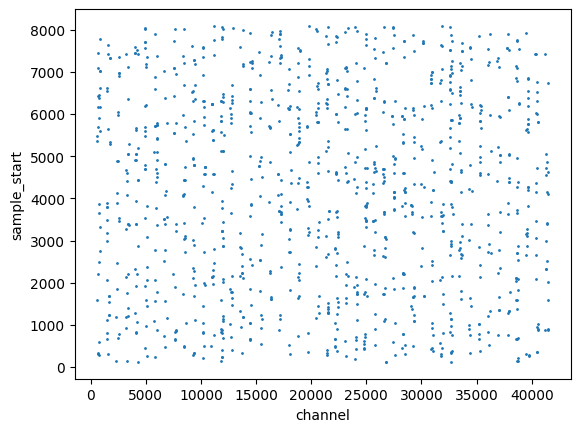

In [81]:
ev_tps.plot.scatter(x='channel', y='sample_start', s=1)
# ev_tps.tpc_view_channel.hist()

In [11]:
from tpvalidator.mcprod.geometry import FDVDGeometry_1x8x6
from rich import print
from rich.table import Table


geo = FDVDGeometry_1x8x6

t=Table('id', 'j (y-index)', 'k (z-index)', 'first chan')
for i in range(geo.num_tpcs):
    j, k = geo.tpc_id_to_grid(i)
    t.add_row(str(i), str(j), str(k), str(i*geo.tpc_tot_num_chans_sim))

print(t)


┏━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━┓
┃ id ┃ j (y-index) ┃ k (z-index) ┃ first chan ┃
┡━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━┩
│ 0  │ 0           │ 0           │ 0          │
│ 1  │ 1           │ 0           │ 864        │
│ 2  │ 2           │ 0           │ 1728       │
│ 3  │ 3           │ 0           │ 2592       │
│ 4  │ 4           │ 0           │ 3456       │
│ 5  │ 5           │ 0           │ 4320       │
│ 6  │ 6           │ 0           │ 5184       │
│ 7  │ 7           │ 0           │ 6048       │
│ 8  │ 0           │ 1           │ 6912       │
│ 9  │ 1           │ 1           │ 7776       │
│ 10 │ 2           │ 1           │ 8640       │
│ 11 │ 3           │ 1           │ 9504       │
│ 12 │ 4           │ 1           │ 10368      │
│ 13 │ 5           │ 1           │ 11232      │
│ 14 │ 6           │ 1           │ 12096      │
│ 15 │ 7           │ 1           │ 12960      │
│ 16 │ 0           │ 2           │ 13824      │
│ 17 │ 1           │ 2           │ 14688      │
│ 18 │ 2           │ 2           │ 15552      │
│ 19 │ 3           │ 2           │ 16416      │
│ 20 │ 4           │ 2           │ 17280      │
│ 21 │ 5           │ 2           │ 18144      │
│ 22 │ 6           │ 2           │ 19008      │
│ 23 │ 7           │ 2           │ 19872      │
│ 24 │ 0           │ 3           │ 20736      │
│ 25 │ 1           │ 3           │ 21600      │
│ 26 │ 2           │ 3           │ 22464      │
│ 27 │ 3           │ 3           │ 23328      │
│ 28 │ 4           │ 3           │ 24192      │
│ 29 │ 5           │ 3           │ 25056      │
│ 30 │ 6           │ 3           │ 25920      │
│ 31 │ 7           │ 3           │ 26784      │
│ 32 │ 0           │ 4           │ 27648      │
│ 33 │ 1           │ 4           │ 28512      │
│ 34 │ 2           │ 4           │ 29376      │
│ 35 │ 3           │ 4           │ 30240      │
│ 36 │ 4           │ 4           │ 31104      │
│ 37 │ 5           │ 4           │ 31968      │
│ 38 │ 6           │ 4           │ 32832      │
│ 39 │ 7           │ 4           │ 33696      │
│ 40 │ 0           │ 5           │ 34560      │
│ 41 │ 1           │ 5           │ 35424      │
│ 42 │ 2           │ 5           │ 36288      │
│ 43 │ 3           │ 5           │ 37152      │
│ 44 │ 4           │ 5           │ 38016      │
│ 45 │ 5           │ 5           │ 38880      │
│ 46 │ 6           │ 5           │ 39744      │
│ 47 │ 7           │ 5           │ 40608      │
└────┴─────────────┴─────────────┴────────────┘